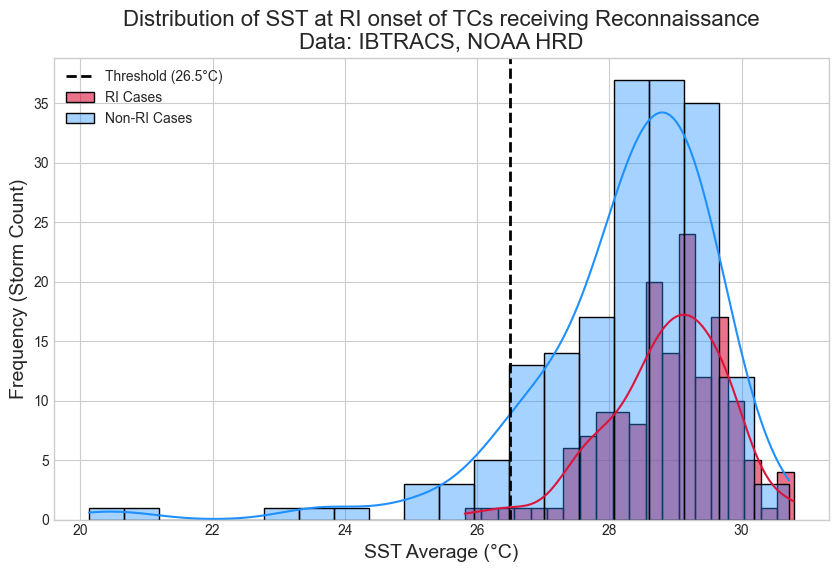

In [6]:
import pandas as pd

df = pd.read_csv('Final_TC_RI_Dataset.csv')

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(10, 6))

# 3. Create overlapping histograms for comparison
# Filter for RI (Target 1) and Non-RI (Target 0)
sns.histplot(data=df[df['Target'] == 1], x='SST_avg', color='crimson', 
             label='RI Cases', kde=True, bins=20, alpha=0.6)
sns.histplot(data=df[df['Target'] == 0], x='SST_avg', color='dodgerblue', 
             label='Non-RI Cases', kde=True, bins=20, alpha=0.4)

# 4. Add the 'Critical Threshold' line at 26.5°C
plt.axvline(x=26.5, color='black', linestyle='--', linewidth=2, label='Threshold (26.5°C)')

# 5. Labeling and Title
plt.title('Distribution of SST at RI onset of TCs receiving Reconnaissance\nData: IBTRACS, NOAA HRD', fontsize=16)
plt.xlabel('SST Average (°C)', fontsize=14)
plt.ylabel('Frequency (Storm Count)', fontsize=14)
plt.legend()

# 6. Save and Show
plt.savefig('SST_Distribution_RI.png', dpi=300)
plt.show()

In [3]:
import pandas as pd

# Load the dataset generated by your ERA5 script
df = pd.read_csv('Final_TC_RI_Dataset.csv')

# Filter for Rapid Intensification cases with SST < 26.5
# We call these 'Thermodynamic Outliers'
low_temp_ri = df[(df['Target'] == 1) & (df['SST_avg'] < 26.5)]

if not low_temp_ri.empty:
    print("Storms that underwent RI below 26.5°C:")
    # Display Name, Year, and the actual SST detected
    print(low_temp_ri[['Name', 'Year', 'SST_avg']].sort_values(by='SST_avg'))
    
    # Save this list for your report/thesis analysis
    low_temp_ri.to_csv('Cool_Water_RI_Outliers.csv', index=False)
else:
    print("No RI cases in this dataset began below the 26.5°C threshold.")

Storms that underwent RI below 26.5°C:
         Name  Year    SST_avg
227  FLORENCE  2018  25.814294
92     BERTHA  2008  26.239130
118     SHARY  2010  26.487878


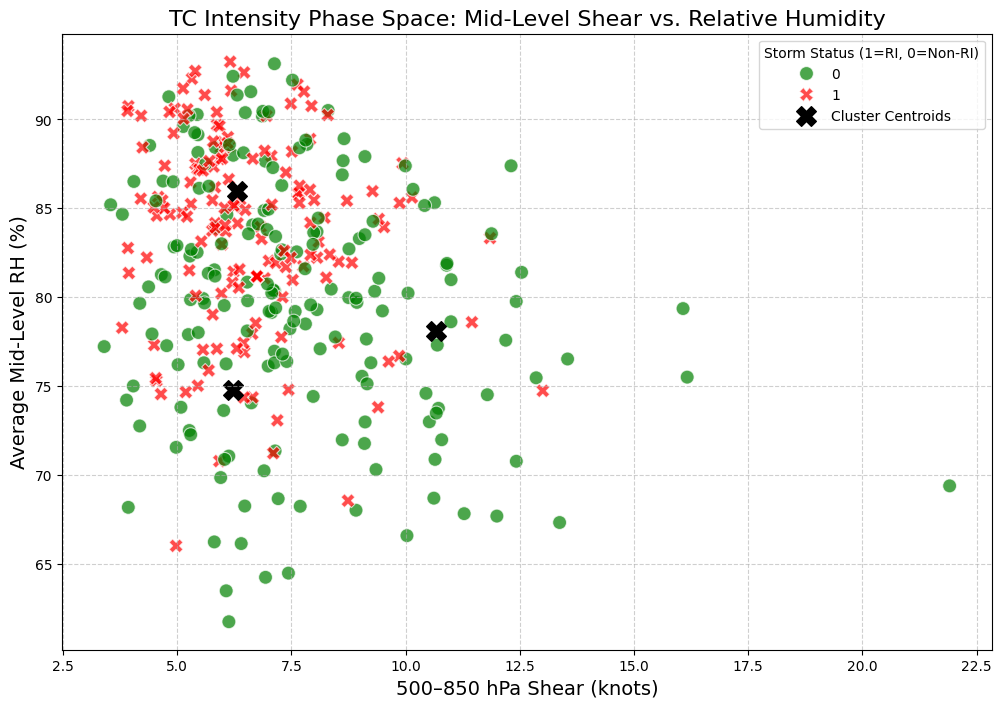

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. Load your ERA5-generated dataset
df = pd.read_csv('Final_TC_RI_Dataset.csv')
df['shear_500_850'] = df['shear_500_850'] / 1.94384
# 2. Prepare the data for clustering
# We only cluster based on the physical parameters, not the Target
features = ['shear_500_850', 'RH_avg']
X = df[features]

# Standardize the features (Crucial for clustering!)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Apply Clustering (Using K-Means as a robust alternative to Isodata)
# We'll look for 3 clusters: 'Optimal RI', 'Marginal', and 'Hostile'
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# 4. Visualization
plt.figure(figsize=(12, 8))

# Plot the actual storm cases
sns.scatterplot(data=df, x='shear_500_850', y='RH_avg', 
                hue='Target', palette={1: 'red', 0: 'green'}, 
                style='Target', s=100, alpha=0.7)

# Add Cluster Centroids to show the 'Centers of Gravity'
centroids = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(centroids[:, 0], centroids[:, 1], c='black', marker='X', s=200, label='Cluster Centroids')

# Labeling
plt.title('TC Intensity Phase Space: Mid-Level Shear vs. Relative Humidity', fontsize=16)
plt.xlabel('500–850 hPa Shear (knots)', fontsize=14)
plt.ylabel('Average Mid-Level RH (%)', fontsize=14)
plt.legend(title='Storm Status (1=RI, 0=Non-RI)')
plt.grid(True, linestyle='--', alpha=0.6)

plt.savefig('TC_EDA_Scatter_Clustering.png', dpi=300)
plt.show()

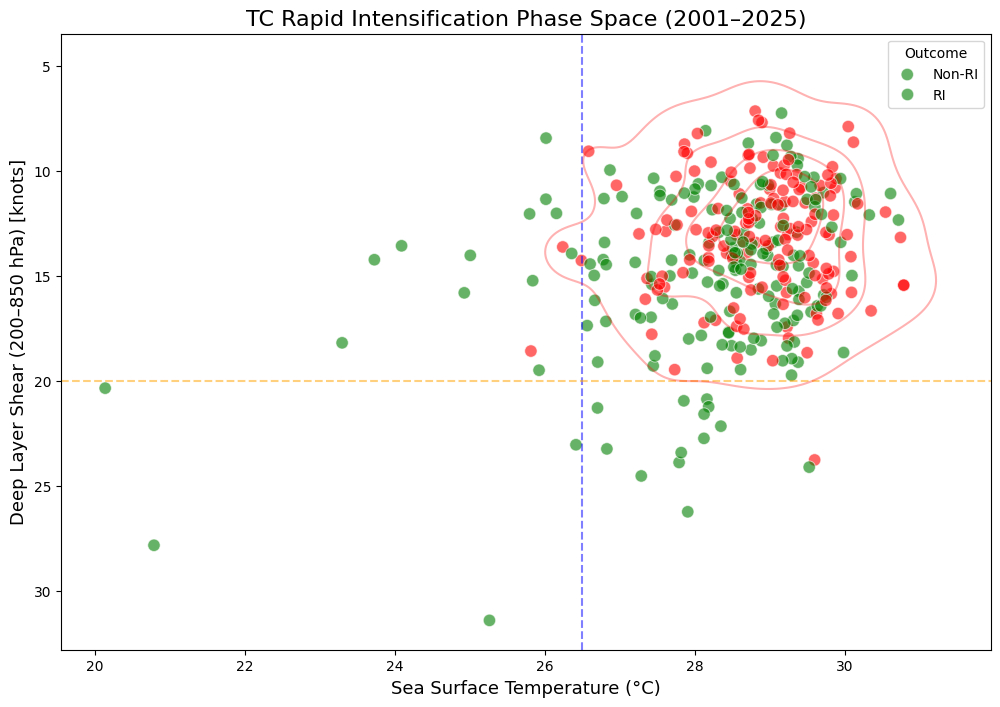

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load your final dataset
df = pd.read_csv('Final_TC_RI_Dataset.csv')
df['shear_200_850'] = df['shear_200_850'] / 1.94384
plt.figure(figsize=(12, 8))

# Create the scatter plot
sns.scatterplot(data=df, x='SST_avg', y='shear_200_850', 
                hue='Target', palette={1: 'red', 0: 'green'}, 
                alpha=0.6, s=80)

# Add the 'Critical Threshold' lines for reference
plt.axvline(x=26.5, color='blue', linestyle='--', alpha=0.5, label='SST Threshold (26.5°C)')
plt.axhline(y=20, color='orange', linestyle='--', alpha=0.5, label='Shear Limit (~20 kts)')

# Scientific Labeling
plt.title('TC Rapid Intensification Phase Space (2001–2025)', fontsize=16)
plt.xlabel('Sea Surface Temperature (°C)', fontsize=13)
plt.ylabel('Deep Layer Shear (200–850 hPa) [knots]', fontsize=13)
plt.gca().invert_yaxis() # Often experts prefer shear 0 at the top (better conditions)
plt.legend(title='Outcome', labels=['Non-RI', 'RI'])

# Add this line before plt.show() to see the probability 'clouds'
sns.kdeplot(data=df[df['Target'] == 1], x='SST_avg', y='shear_200_850', 
            color='red', levels=5, alpha=0.3)
plt.show()

In [9]:
import pandas as pd
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# 1. Load your final engineered dataset
df = pd.read_csv('Final_TC_RI_Dataset.csv')

# 2. Define Features (X) and Target (y)
# Drop metadata like Name/Year; include all physics parameters
features = ['shear_200_850', 'shear_500_850', 'shear_200_500', 
            'shear_300_800', 'shear_850_1000', 'RH_avg', 'SST_avg', 
            'v_0', 'ROCI', 'RMW']

X = df[features]
y = df['Target']

# 3. Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# 4. Initialize XGBoost with GPU Support
model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=50,
    tree_method='hist', # This uses your RTX 5060!
    use_label_encoder=False,
    eval_metric='logloss'
)

# 5. Train and Evaluate
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[28  9]
 [10 22]]
              precision    recall  f1-score   support

           0       0.74      0.76      0.75        37
           1       0.71      0.69      0.70        32

    accuracy                           0.72        69
   macro avg       0.72      0.72      0.72        69
weighted avg       0.72      0.72      0.72        69



c:\Users\Sohum Chatterjee\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\xgboost\training.py:200: UserWarning: [17:32:26] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Load the Dataset
df = pd.read_csv('Final_TC_RI_Dataset.csv')

# Handle any remaining NaNs in RMW/ROCI (Random Forest doesn't like NaNs)
df = df.dropna(subset=['Target']) # Ensure Target is clean
df = df.fillna(df.median(numeric_only=True))

# 2. Define Features
features = [
    'shear_200_850', 'shear_500_850', 'shear_200_500', 
    'shear_300_800', 'shear_850_1000', 'RH_avg', 'SST_avg', 
    'v_0', 'ROCI', 'RMW'
]

X = df[features]
y = df['Target']

# 3. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 4. Initialize and Train Random Forest
rf_model = RandomForestClassifier(
    n_estimators=400,
    max_depth=6, # Keep depth shallow to prevent memorizing storm names
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1, # Uses all cores of your Ryzen 9,
    oob_score=True
)

rf_model.fit(X_train, y_train)

# 5. Evaluate
# Get the raw probabilities
y_probs = rf_model.predict_proba(X_test)[:, 1]

# Adjust threshold to be more 'aggressive' (catch more RI)
custom_threshold = 0.45
y_pred_aggressive = (y_probs >= custom_threshold).astype(int)

from sklearn.metrics import classification_report
print(f"--- Results with Threshold {custom_threshold} ---")
print(classification_report(y_test, y_pred_aggressive))

--- Results with Threshold 0.45 ---
              precision    recall  f1-score   support

           0       0.83      0.68      0.75        37
           1       0.69      0.84      0.76        32

    accuracy                           0.75        69
   macro avg       0.76      0.76      0.75        69
weighted avg       0.77      0.75      0.75        69



C:\Users\Sohum Chatterjee\AppData\Local\Temp\ipykernel_27872\1692142306.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


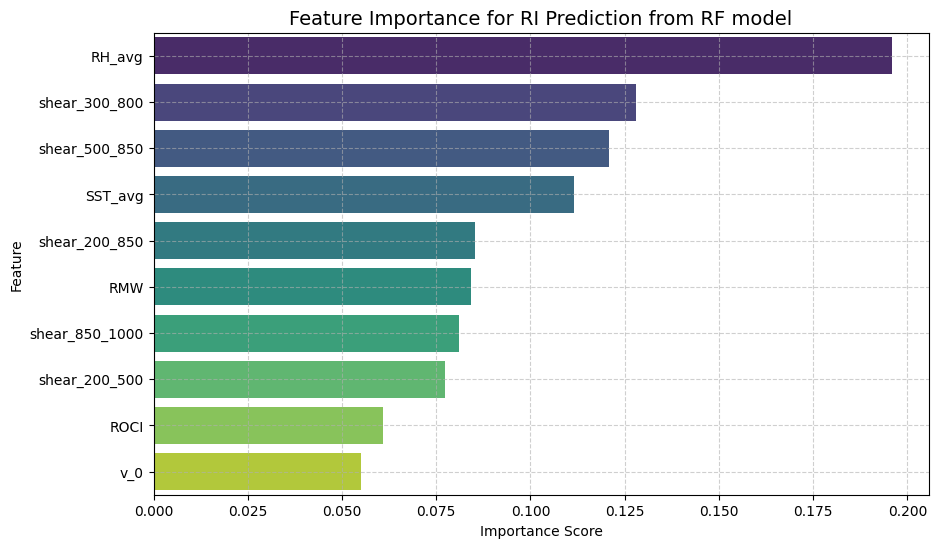

In [7]:
# Extract and Plot Importance
importances = rf_model.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
#add grid:
plt.grid(True, linestyle='--', alpha=0.6)
plt.title('Feature Importance for RI Prediction from RF model', fontsize=14)
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()

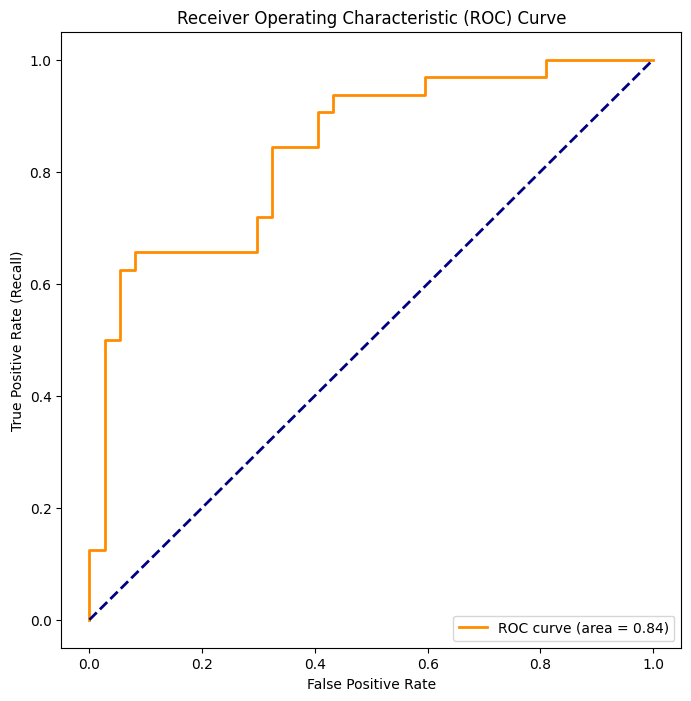

In [5]:
from sklearn.metrics import roc_curve, roc_auc_score

auc = roc_auc_score(y_test, y_probs)
fpr, tpr, thresholds = roc_curve(y_test, y_probs)

plt.figure(figsize=(8, 8))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

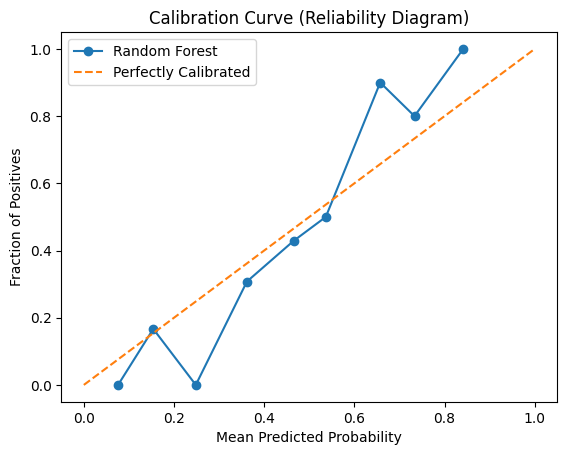

In [6]:
from sklearn.calibration import calibration_curve
prob_true, prob_pred = calibration_curve(y_test, y_probs, n_bins=10)

plt.plot(prob_pred, prob_true, marker='o', label='Random Forest')
plt.plot([0, 1], [0, 1], linestyle='--', label='Perfectly Calibrated')
plt.title('Calibration Curve (Reliability Diagram)')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.legend()
plt.show()

In [8]:
#OOB score:
print(f"OOB score: {rf_model.oob_score_:.2f}")

OOB score: 0.63


In [8]:
# 1. Create the results DataFrame from your test set
results_df = X_test.copy()

# 2. Add the prediction metrics
results_df['Actual'] = y_test
results_df['Prob_RI'] = y_probs
results_df['Prediction'] = (y_probs >= 0.45).astype(int)
results_df['Error'] = abs(results_df['Actual'] - results_df['Prob_RI'])

# 3. Join with the metadata from your original master dataframe
# We use the index because X_test and y_test still 'remember' their original row numbers
results_df = results_df.join(df[['Name', 'Year']])

# 4. Display the top "Surprises" (where the model was most confident but wrong)
# High Error = Model was very confident in the wrong outcome
top_misses = results_df.sort_values(by='Error', ascending=False).head(10)

print("Top 10 Storms the Model Struggled With:")
print(top_misses[['Name', 'Year', 'Actual', 'Prob_RI', 'Error']])

# 5. Optional: Save these for your report discussion
top_misses.to_csv('Model_Failure_Analysis.csv', index=False)

Top 10 Storms the Model Struggled With:
         Name  Year  Actual   Prob_RI     Error
141     KATIA  2011       1  0.196752  0.803248
330    NADINE  2024       0  0.749570  0.749570
124   MALAKAS  2010       1  0.329552  0.670448
284    BONNIE  2022       0  0.619256  0.619256
302     LIDIA  2023       1  0.390168  0.609832
262   DOUGLAS  2020       1  0.395288  0.604712
271      ELSA  2021       1  0.399556  0.600444
224     BERYL  2018       1  0.454590  0.545410
176    BERTHA  2014       1  0.455094  0.544906
333  HUMBERTO  2025       1  0.458008  0.541992
